# **SpecialTopic_HM02 – Sentiment Analysis on Yelp Reviews**

---

## **1) Download + Extract + Sampling Yelp Review Dataset**

In [2]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import random


In [3]:

import requests, zipfile, tarfile, io, random, pandas as pd, os

# --- Download Yelp ZIP ---
url = "https://business.yelp.com/external-assets/files/Yelp-JSON.zip"
headers = {'User-Agent': 'Mozilla/5.0'}

print("Downloading Yelp dataset...")
resp = requests.get(url, stream=True, headers=headers)
resp.raise_for_status()

with open("Yelp-JSON.zip","wb") as f:
    for chunk in resp.iter_content(chunk_size=8192):
        f.write(chunk)
print("ZIP downloaded ✓")

# --- Extract ZIP ---
with zipfile.ZipFile("Yelp-JSON.zip","r") as z:
    z.extractall("yelp_zip")
print("ZIP extracted ✓")

# --- Extract TAR ---
tar_path = "yelp_zip/Yelp JSON/yelp_dataset.tar"
with tarfile.open(tar_path, "r") as tar:
    tar.extractall("yelp_dataset")
print("TAR extracted ✓")

# Sampling only review file (needed for sentiment analysis)
review_file = "yelp_dataset/yelp_academic_dataset_review.json"
sample_rate = 0.10   # 10% sample to make it lighter

def sample_json(filename, rate):
    lines=[]
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            if random.random() < rate:
                lines.append(line)
    return pd.read_json(io.StringIO(''.join(lines)), lines=True)

df_review = sample_json(review_file, sample_rate)
print("Sampling complete ✓")
print(df_review.shape)

df_review.head()


ZIP downloaded ✓
ZIP extracted ✓


/tmp/ipython-input-1237416684.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("yelp_dataset")


TAR extracted ✓
Sampling complete ✓
(699181, 9)


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,rGQRf8UafX7OTlMNN19I8A,1WHRWwQmZOZDAhp2Qyny4g,uMvVYRgGNXf5boolA9HXTw,5,2,0,0,My experience with Shalimar was nothing but wo...,2015-06-21 14:48:06
1,lUUhg8ltDsUZ9h0xnwY4Dg,RreNy--tOmXMl1en0wiBOg,cPepkJeRMtHapc_b2Oe_dw,4,1,0,1,I was really between 3 and 4 stars for this on...,2018-07-17 03:30:07
2,qGQvUHmC02PAZW3H1WTIfw,RRTQpg8hutdimzAYuP_Hbw,eaJCpC6IhYphj7bwCDHTwQ,5,0,0,0,Stopped by after a Sunday morning walk in the ...,2015-08-30 13:41:47
3,rV6AWGN4rYORMQY8dVP41g,dKoIp8vsKFH4cbmGSYy2IQ,0ICfbEImE0gUZc4kSZ7QHg,5,1,0,0,Replaced 2 old 70s lennox with 2 new ones. Th...,2013-11-14 04:58:09
4,DWbmJF84jRrGaJRmlSSnYQ,aWlojpSpzEICTza3RgGJgg,SIoCIxjn4jLt2O-4DajWJw,4,0,0,0,My go-to spot on a Saturday night! I was real ...,2015-11-18 17:47:29


## **2) Create Sentiment Labels (Positive / Negative)**

In [4]:

# Positive = 3, 4, 5 stars
# Negative = 1, 2 stars
df_review['label'] = df_review['stars'].apply(lambda x: 1 if x >= 3 else 0)

df_review[['text','stars','label']].head()


,text,stars,label
0,My experience with Shalimar was nothing but wo...,5,1
1,I was really between 3 and 4 stars for this on...,4,1
2,Stopped by after a Sunday morning walk in the ...,5,1
3,Replaced 2 old 70s lennox with 2 new ones. Th...,5,1
4,My go-to spot on a Saturday night! I was real ...,4,1


## **3) Train / Test / Validation Split**

In [5]:

from sklearn.model_selection import train_test_split

train, test = train_test_split(df_review, test_size=0.2, random_state=42)
train, val  = train_test_split(train, test_size=0.1, random_state=42)

print(train.shape, val.shape, test.shape)


(503409, 10) (55935, 10) (139837, 10)


## **4) Class Distribution Visualization**

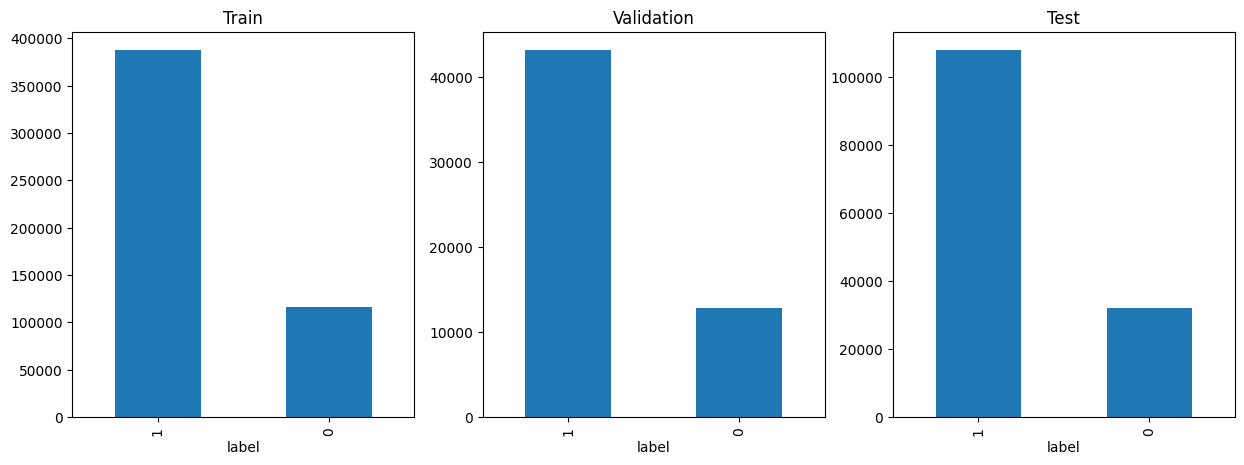

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1,3, figsize=(15,5))

train['label'].value_counts().plot(kind='bar', ax=axs[0], title='Train')
val['label'].value_counts().plot(kind='bar', ax=axs[1], title='Validation')
test['label'].value_counts().plot(kind='bar', ax=axs[2], title='Test')

plt.show()


## **5) WordCloud: Positive vs Negative Reviews**

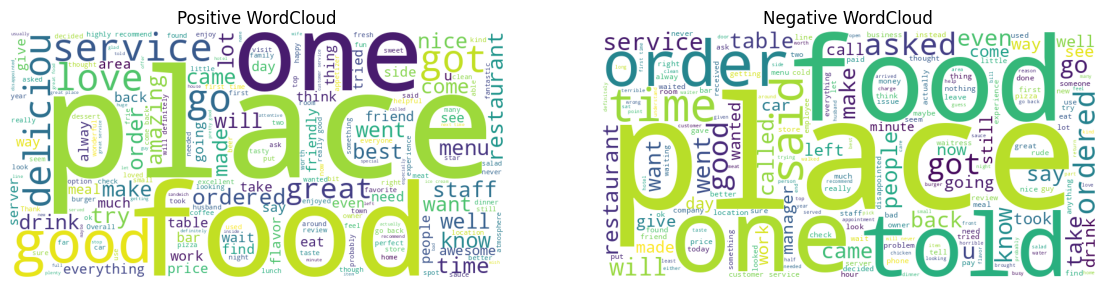

In [7]:

from wordcloud import WordCloud

pos_text = " ".join(train[train['label']==1]['text'])
neg_text = " ".join(train[train['label']==0]['text'])

wc_pos = WordCloud(background_color='white', width=800, height=400).generate(pos_text)
wc_neg = WordCloud(background_color='white', width=800, height=400).generate(neg_text)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1); plt.imshow(wc_pos); plt.axis('off'); plt.title("Positive WordCloud")
plt.subplot(1,2,2); plt.imshow(wc_neg); plt.axis('off'); plt.title("Negative WordCloud")
plt.show()


## **6) Text Preprocessing (Lowercase + Stopwords removal)**

In [8]:

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(t):
    t = t.lower()
    tokens = [w for w in t.split() if w not in stop_words]
    return " ".join(tokens)

train['clean'] = train['text'].apply(clean_text)
val['clean']   = val['text'].apply(clean_text)
test['clean']  = test['text'].apply(clean_text)

train[['text','clean']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,text,clean
19835,Great service but call ahead always to make su...,great service call ahead always make sure avai...
182473,"Went here with my husband, another couple and ...","went husband, another couple 3 month old. over..."
99114,City Park is one large park that has a lot of ...,city park one large park lot great things keep...
185360,Horrible drive through. I'm writing during my ...,horrible drive through. writing 25th minute li...
1234,Delicious avocado toast. The bread used for th...,delicious avocado toast. bread used toast whol...


## **7) Baseline Model – Random Classifier**

Random Classifier Report:
              precision    recall  f1-score   support

           0       0.23      0.50      0.32     32084
           1       0.77      0.50      0.61    107753

    accuracy                           0.50    139837
   macro avg       0.50      0.50      0.46    139837
weighted avg       0.65      0.50      0.54    139837



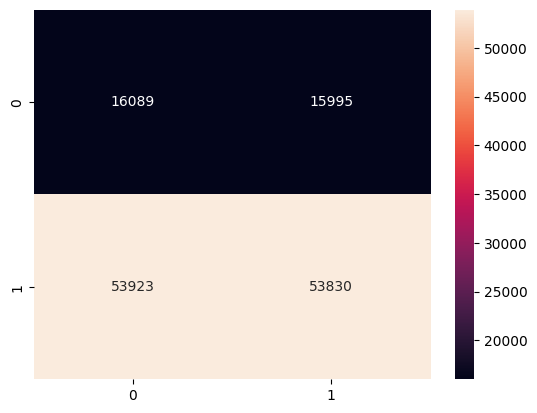

In [9]:

y_true = test['label'].tolist()
y_pred_random = [random.choice([0,1]) for _ in range(len(test))]

print("Random Classifier Report:")
print(classification_report(y_true, y_pred_random))

cm = confusion_matrix(y_true, y_pred_random)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()


## **8) Rule‑Based Sentiment Classifier (Like SnappFood Exercise)**

              precision    recall  f1-score   support

           0       0.44      0.82      0.57     32084
           1       0.93      0.69      0.79    107753

    accuracy                           0.72    139837
   macro avg       0.68      0.75      0.68    139837
weighted avg       0.82      0.72      0.74    139837



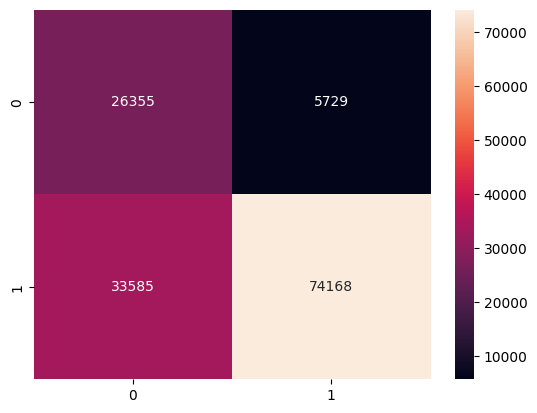

In [10]:

from collections import Counter

# Extract frequent keywords for each class
pos_words = " ".join(train[train['label']==1]['clean']).split()
neg_words = " ".join(train[train['label']==0]['clean']).split()

pos_top = set([w for w,c in Counter(pos_words).most_common(200)])
neg_top = set([w for w,c in Counter(neg_words).most_common(200)])

# remove common words (noise)
common = pos_top & neg_top
pos_unique = pos_top - common
neg_unique = neg_top - common

def predict_rule(text):
    tokens = set(text.split())
    pc = len(tokens & pos_unique)
    nc = len(tokens & neg_unique)
    return 1 if pc > nc else 0

y_pred_rule = [predict_rule(t) for t in test['clean']]
print(classification_report(y_true, y_pred_rule))

cm = confusion_matrix(y_true, y_pred_rule)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()


## **9) BERT Sentiment Analysis (DistilBERT English)**

100%|██████████| 8740/8740 [26:38<00:00,  5.47it/s]


              precision    recall  f1-score   support

           0       0.69      0.94      0.80     32084
           1       0.98      0.88      0.92    107753

    accuracy                           0.89    139837
   macro avg       0.84      0.91      0.86    139837
weighted avg       0.91      0.89      0.90    139837



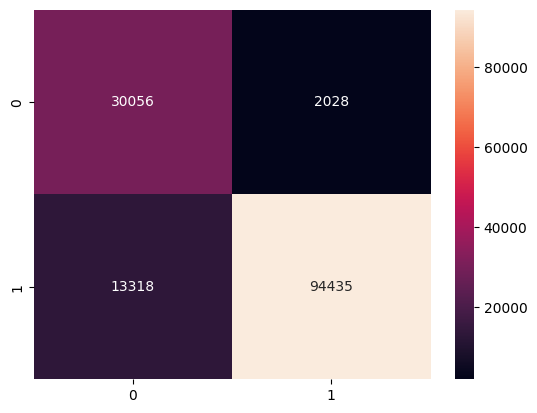

In [11]:

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm import tqdm

model_name = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def predict_bert(texts):
    preds = []
    for i in tqdm(range(0, len(texts), 16)):
        batch = texts[i:i+16]
        tok = tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to(device)

        with torch.no_grad():
            out = model(**tok)

        preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
    return preds

y_pred_bert = predict_bert(test['text'].tolist())

print(classification_report(y_true, y_pred_bert))

cm = confusion_matrix(y_true, y_pred_bert)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()
